<a href="https://colab.research.google.com/github/raheelam98/DataAnalysis/blob/main/EDA_Projects/Zameen_EDA_Project/NoteBook/Zameen_EDA_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Zameen.com**

Tester

In [6]:
!pip install fuzzywuzzy

In [8]:
#Mount Google Drive in Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
#List Files in a Folder
!ls /content/drive/MyDrive/EDA/

ai_adoption_dataset.csv  cubic_zirconia.csv		    Scarped_Zameen.xlsx
bus_fare_dataset.csv	 pakistan_intellectual_capital.csv


In [10]:
import pandas as pd

# Correct path and filename
df = pd.read_excel('/content/drive/MyDrive/EDA/Scarped_Zameen.xlsx')


In [11]:
# modules we'll use
# import pandas as pd
import numpy as np

# helpful modules
import fuzzywuzzy # pip install fuzzywuzzy
from fuzzywuzzy import process

/usr/local/lib/python3.11/dist-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [12]:
df.head()

,Title,URL,City,Type,Area,Price,Purpose,Location,Description,Built in year,...,Nearby Schools,Nearby Hospitals,Nearby Shopping Malls,Nearby Restaurants,Distance From Airport (kms),Nearby Public Transport Service,Other Nearby Places,Maintenance Staff,Security Staff,Other Facilities
0,Hmr Waterfront 2 Bed Room Premium Apartment On...,https://www.zameen.com/Property/dha_phase_8_hm...,Karachi,Flat,128 Sq. Yd.,PKR\n4.75 Crore,For Sale,"DHA Defence, Karachi, Sindh",SAIMA MARINA RESIDENCE HMR WATERFRONT\nINVESTO...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Chance Deal! Luxury 2 Bedroom Seafront Apartme...,https://www.zameen.com/Property/dha_defence_dh...,Karachi,Flat,161 Sq. Yd.,PKR\n6.25 Crore,For Sale,"DHA Defence, Karachi, Sindh",Live the Seafront Dream at H&S Residence \n2 B...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Luxury 1 Bed At H& S Residence By Japanese Arc...,https://www.zameen.com/Property/dha_phase_8_hm...,Karachi,Flat,111 Sq. Yd.,PKR\n3.45 Crore,For Sale,"DHA Defence, Karachi, Sindh",Live the Seafront Dream at H&S Residence \n1 B...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Luxury 1 Bed Seafront Apartment at HMR waterfr...,https://www.zameen.com/Property/dha_phase_8_hm...,Karachi,Flat,106 Sq. Yd.,PKR\n2.98 Crore,For Sale,"DHA Defence, Karachi, Sindh",Chance Deal at HMR Waterfront 1-Bed Apartment ...,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2 Bed Apartment For Booking On 3 Years | Saima...,https://www.zameen.com/Property/dha_phase_8_hm...,Karachi,Flat,156 Sq. Yd.,PKR\n4.65 Crore,For Sale,"DHA Defence, Karachi, Sindh",HMR WATERFRONT \n\nOwn Your Dream Apartment in...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# 2-i) View basic info
# Dataset Info : Show index range, column types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18255 entries, 0 to 18254
Data columns (total 59 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Title                            18239 non-null  object 
 1   URL                              18255 non-null  object 
 2   City                             18255 non-null  object 
 3   Type                             18239 non-null  object 
 4   Area                             18239 non-null  object 
 5   Price                            18239 non-null  object 
 6   Purpose                          18239 non-null  object 
 7   Location                         18239 non-null  object 
 8   Description                      14893 non-null  object 
 9   Built in year                    11940 non-null  float64
 10  Parking Spaces                   9656 non-null   float64
 11  Double Glazed Windows            0 non-null      float64
 12  Central Air Condit

In [14]:
# Total number of rows in dataset
len(df)

18255

In [15]:
# Identify missing values using
df.isnull().sum()

,0
Title,16
URL,0
City,0
Type,16
Area,16
Price,16
Purpose,16
Location,16
Description,3362
Built in year,6315


In [16]:
# Drop All Columns with Only Missing Values
df.dropna(axis=1, how='all', inplace=True)

In [17]:
# View All Column Names
df.columns

Index(['Title', 'URL', 'City', 'Type', 'Area', 'Price', 'Purpose', 'Location',
       'Description', 'Built in year', 'Parking Spaces', 'Floors', 'Bedrooms',
       'Bathrooms', 'Servant Quarters', 'Kitchens', 'Store Rooms'],
      dtype='object')

In [18]:
# statistical description of datafram
df.describe()

,Built in year,Parking Spaces,Floors,Servant Quarters,Kitchens,Store Rooms
count,11940.000000,9656.000000,8366.000000,9657.000000,13256.000000,9719.000000
mean,1967.123744,5.251833,2.393677,1.236823,1.686859,1.169565
std,1949.941225,41.917894,22.849369,0.706476,2.022453,0.495977
min,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2020.000000,1.000000,2.000000,1.000000,1.000000,1.000000
50%,2024.000000,2.000000,2.000000,1.000000,2.000000,1.000000
75%,2025.000000,3.000000,2.000000,1.000000,2.000000,1.000000
max,202122.000000,2015.000000,2018.000000,22.000000,211.000000,18.000000


In [19]:
# Check for total number of duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Duplicate Rows Detected: {duplicate_count}")

# View sample duplicate entries (if any)
if duplicate_count > 0:
    print("Sample Duplicate Rows:")
    display(df[df.duplicated()].head())

# Remove duplicate rows permanently
df.drop_duplicates(inplace=True)

# Confirm removal
print(f"\n Duplicates Removed. New shape: {df.shape}")


Duplicate Rows Detected: 0

 Duplicates Removed. New shape: (18255, 17)


In [20]:
# Check for duplicates based on these columns
df.duplicated(subset=['Title', 'Area', 'Price']).sum()


np.int64(559)

In [21]:
# Drop duplicates based on key listing attributes
df.drop_duplicates(subset=['Title', 'Area', 'Price'], inplace=True)

# Confirm shape after cleanup
print(f"Clean dataset shape: {df.shape}")


Clean dataset shape: (17696, 17)


In [ ]:
# # # Categorical Column Analysis
# # print("\n\n. Categorical Column Analysis")

# for col in ['Price', 'Area']:

#     # Print column header
#     print(f"\nAnalysis for column: ' {col} ' ")

#     # Show unique values (categories present in the column)
#     print("\nUnique values:", df[col].unique())

#     # Show frequency count of each category
#     print("\nUnique Value counts:", df[col].value_counts())

#     print("---------------------------------------------")


In [22]:
print("Price Unique Values :", df['Price'].nunique()) # count of distinct values
print("Price Duplicates.   :", df['Price'].duplicated().sum())

print("\nArea Unique Values:", df['Area'].nunique()) # # count of distinct values
print("Area Duplicates:    :", df['Area'].duplicated().sum())

Price Unique Values : 1022
Price Duplicates.   : 16673

Area Unique Values: 468
Area Duplicates:    : 17227


In [23]:
# View messy columns
print("\nTop 10 Price Values:\n", df['Price'].value_counts().head(10))
print("\n\nTop 10 Area Values:\n", df['Area'].value_counts().head(10))



Top 10 Price Values:
 Price
PKR\n60 Thousand    261
PKR\n45 Thousand    226
PKR\n50 Thousand    221
PKR\n70 Thousand    211
PKR\n3.5 Crore      208
PKR\n80 Thousand    204
PKR\n65 Thousand    203
PKR\n2.5 Crore      201
PKR\n55 Thousand    198
PKR\n90 Thousand    196
Name: count, dtype: int64


Top 10 Area Values:
 Area
5 Marla        3355
10 Marla       2889
1 Kanal        2047
7 Marla         847
6 Marla         445
4 Marla         412
8 Marla         354
500 Sq. Yd.     349
3 Marla         330
12 Marla        321
Name: count, dtype: int64


In [24]:
# Clean messy columns ( e.g., remove commas, PKR symbols)
import numpy as np

def clean_price_column(series):
    cleaned = (
        series.astype(str)
              .str.replace(',', '', regex=False)
              .str.replace('PKR', '', regex=False)
              .str.replace('Rs.', '', regex=False)
              .str.strip()
              .str.lower()
    )

    # Convert Lakh and Crore to numbers
    def convert_units(value):
        try:
            if 'crore' in value:
                num = float(value.replace('crore', '').strip())
                return num * 1e7
            elif 'lakh' in value:
                num = float(value.replace('lakh', '').strip())
                return num * 1e5
            else:
                return float(value)
        except:
            return np.nan

    return cleaned.apply(convert_units)


In [25]:
# View Price
df['Price'] = clean_price_column(df['Price'])

# Preview result
print(df[['Price']].head())


        Price
0  47500000.0
1  62500000.0
2  34500000.0
3  29800000.0
4  46500000.0


In [26]:
# Convert area units (marla/kanal/sqft → uniform sqft), if required

def clean_area_column(series):
    unit_map = {
        'marla': 272.25,
        'kanal': 5445,
        'sq yards': 9,
        'sq. yards': 9,
        'sq meter': 10.7639,
        'sq. meter': 10.7639,
        'square meter': 10.7639,
        'sq ft': 1,
        'sq. ft': 1,
        'square feet': 1
    }

    cleaned = (
        series.astype(str)
              .str.replace(',', '', regex=False)
              .str.lower()
              .str.strip()
    )

    def convert_area(value):
        for unit in unit_map:
            if unit in value:
                try:
                    num = float(value.replace(unit, '').strip())
                    return num * unit_map[unit]
                except:
                    return np.nan
        try:
            return float(value)  # If it's already in sqft
        except:
            return np.nan

    return cleaned.apply(convert_area)


In [27]:
# View Area
df['Area'] = clean_area_column(df['Area'])
df['Area'].dropna().head(10).tolist()


[1932.975,
 816.75,
 2178.0,
 2722.5,
 2722.5,
 2178.0,
 2722.5,
 1932.975,
 2994.75,
 5445.0]

In [30]:
# # Categorical Column Analysis
# print("\n\n. Categorical Column Analysis")

# for col in df.columns:

#     # Print column header
#     print(f"\nAnalysis for column: ' {col} ' ")

#     # Show unique values (categories present in the column)
#     print("\nUnique values:", df[col].unique())

#     # Show frequency count of each category
#     print("\nUnique Value counts:", df[col].value_counts())

#     print("---------------------------------------------")


In [33]:
# Integer count of distinct values
for column in df:

    # Show unique values
    print(column,df[column].nunique())

Title 16064
URL 17696
City 83
Type 7
Area 216
Price 904
Purpose 2
Location 1048
Description 13437
Built in year 95
Parking Spaces 46
Floors 20
Bedrooms 23
Bathrooms 17
Servant Quarters 14
Kitchens 10
Store Rooms 10


In [34]:
# 3. Missing Values Treatment

# Missing Values - Function
import pandas as pd

def check_missing_values(df):
    """
    Returns a DataFrame summarizing missing values in the input DataFrame.

    Columns:
    - 'Missing Values': total number of missing values in each column
    - 'Percentage (%)': percentage of missing values in each column
    """
    # 1. Total missing values in each column
    missing_counts = df.isnull().sum()

    # 2. Percentage of missing values
    missing_percent = (missing_counts / len(df)) * 100

    # 3. Combine into a single DataFrame
    missing_summary = pd.DataFrame({
        'Missing Values': missing_counts,
        'Percentage (%)': missing_percent.round(2)
    })

    # 4. Filter only columns with missing values
    missing_summary = missing_summary[missing_summary['Missing Values'] > 0]

    return missing_summary

# calling function
print("\n\nSummary of Missing Values:")

missing_info = check_missing_values(df)
print(missing_info)



Summary of Missing Values:
                  Missing Values  Percentage (%)
Title                          1            0.01
Type                           1            0.01
Area                        2803           15.84
Price                       3480           19.67
Purpose                        1            0.01
Location                       1            0.01
Description                 3255           18.39
Built in year               6081           34.36
Parking Spaces              8266           46.71
Floors                      9593           54.21
Bedrooms                       1            0.01
Bathrooms                      1            0.01
Servant Quarters            8313           46.98
Kitchens                    4818           27.23
Store Rooms                 8223           46.47


In [35]:
# Check Missing Values (before filling)
print(df[['City', 'Price']].isnull().sum())


City        0
Price    3480
dtype: int64


In [36]:
# Fix column names with whitespace
df.columns = df.columns.str.strip()

# Categorical Column
df['City'] = df['City'].fillna(df['City'].mode()[0])

# Numerical Column
df['Price'] = df['Price'].fillna(df['Price'].mean())


In [101]:
# confirm the exact value that was used for imputation
print("Used mode for City:", df['City'].mode()[0])

print("Used mean for Price:", df['Price'].mean())


Used mode for City: Karachi
Used mean for Price: 36945247.819358476


In [68]:
# Check Missing Values (after filling)
print(df[['City', 'Price']].isnull().sum())


City     0
Price    0
dtype: int64


In [103]:
#  Show If 'posting_date' Was Processed : To confirm if the column exists and was filled:
if 'posting_date' in df.columns:
    print(df['posting_date'].isnull().sum())
    print(df['posting_date'].head())
else:
    print("No 'posting_date' column found.")

# Only do this if 'posting_date' exists
if 'posting_date' in df.columns:
    df['posting_date'] = df['posting_date'].fillna(method='ffill')



No 'posting_date' column found.


In [107]:
# # Remove extra spaces : Strip whitespace from columns
df.columns = df.columns.str.strip()

In [108]:
# column names
print(df.columns.tolist())


['Title', 'URL', 'City', 'Type', 'Area', 'Price', 'Purpose', 'Location', 'Description', 'Built in year', 'Parking Spaces', 'Floors', 'Bedrooms', 'Bathrooms', 'Servant Quarters', 'Kitchens', 'Store Rooms']


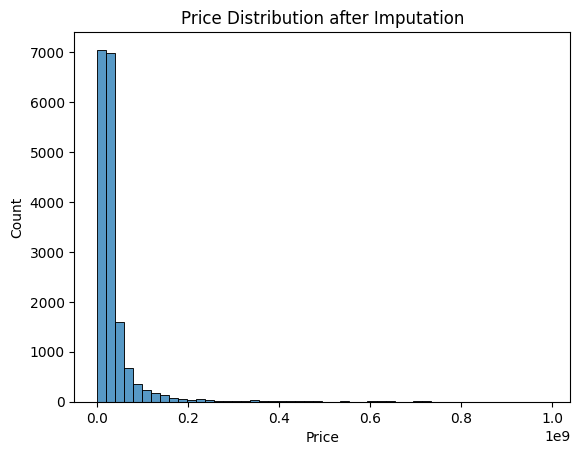

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Price'], bins=50)
plt.title('Price Distribution after Imputation')
plt.show()


In [74]:
# 4. Data Cleaning & Consistency

# # Remove extra spaces : Strip whitespace from columns
df['City'] = df['City'].str.strip()

In [75]:
# get all the unique values in the 'City' column

df['City']=df['City'].str.lower()

cities = df['City'].unique()

# print(cities)

# sort them alphabetically and then take a closer look
cities.sort()
cities


array(['abbottabad', 'attock', 'bahawalpur', 'buner', 'burewala',
       'chakwal', 'chilas', 'chiniot', 'daska', 'dera ghazi khan',
       'dera ismail khan', 'faisalabad', 'fateh jang', 'galyat', 'gharo',
       'gujar khan', 'gujranwala', 'gujrat', 'gwadar', 'hafizabad',
       'haripur', 'hyderabad', 'islamabad', 'jamshoro', 'jhang', 'jhelum',
       'karachi', 'kasur', 'kharian', 'lahore', 'lalamusa', 'lodhran',
       'mardan', 'mirpur', 'mirpur khas', 'multan', 'murree', 'nan',
       'nowshera', 'okara', 'pakpattan', 'peshawar', 'quetta',
       'rahim yar khan', 'rawalpindi', 'sadiqabad', 'sahiwal',
       'sarai alamgir', 'sargodha', 'sheikhupura', 'sialkot', 'sukkur',
       'swat', 'talagang', 'taxila', 'vehari', 'wah'], dtype=object)

In [76]:
# get the top 10 closest matches to "south korea"
matches = fuzzywuzzy.process.extract("abbottabad", cities, limit=5)

# take a look at them
matches

[('abbottabad', 100),
 ('hafizabad', 53),
 ('islamabad', 53),
 ('sadiqabad', 53),
 ('faisalabad', 50)]

In [106]:
# 4. Data Cleaning & Consistency

# FuzzyWuzzy

# function to replace rows in the provided column of the provided dataframe
# that match the provided string above the provided ratio with the provided string
def replace_matches_in_column(df, column, string_to_match, min_match = 95):
    # get a list of unique strings
    strings = df[column].unique()

    # get the top 10 closest matches to our input string
    matches = fuzzywuzzy.process.extract(string_to_match, strings,
                                         limit=5)

    # only get matches with a ratio > 95
    close_matches = [matches[0] for matches in matches if matches[1] >= min_match]

    # get the rows of all the close matches in our dataframe
    rows_with_matches = df[column].isin(close_matches)

    # replace all rows with close matches with the input matches
    df.loc[rows_with_matches, column] = string_to_match

    # let us know the function's done
    #print("All done!")

    print(f"Standardized to '{string_to_match}': {close_matches}\n")
    return df

In [107]:
replace_matches_in_column(df=df, column='City', string_to_match="Islamabad",min_match = 97)
df.City.unique()

Standardized to 'Islamabad': ['Islamabad']



array(['Islamabad', 'lahore', 'abbottabad', 'attock', 'bahawalpur',
       'buner', 'burewala', 'chakwal', 'chilas', 'chiniot', 'daska',
       'dera ghazi khan', 'dera ismail khan', 'faisalabad', 'fateh jang',
       'galyat', 'gharo', 'gujar khan', 'gujranwala', 'gujrat', 'gwadar',
       'hafizabad', 'haripur', 'hyderabad', 'jamshoro', 'jhang', 'jhelum',
       'karachi', 'kasur', 'kharian', 'lalamusa', 'lodhran', 'mardan',
       'mirpur', 'mirpur khas', 'multan', 'murree', 'nowshera', 'okara',
       'pakpattan', 'peshawar', 'quetta', 'rahim yar khan', 'rawalpindi',
       'sadiqabad', 'sahiwal', 'sarai alamgir', 'sargodha', 'sheikhupura',
       'sialkot', 'sukkur', 'swat', 'talagang', 'taxila', 'vehari', 'wah',
       'nan'], dtype=object)

In [87]:
#View Unique Values

df['Type'] = df['Type'].astype(str).str.strip().str.lower()  # clean whitespace
df['Type'].value_counts()


,count
Type,
house,13037
flat,2848
upper portion,1213
lower portion,554
room,43
nan,1


In [98]:
import numpy as np

# Replace string 'nan' and real NaN values with actual np.nan
df['Type'] = df['Type'].replace('nan', np.nan)
df['Type'] = df['Type'].replace('none', np.nan)  # if exists


In [100]:
# Fill missing with mode (most common type)
df['Type'] = df['Type'].fillna(df['Type'].mode()[0])


In [101]:
# Combine Similar Types : group upper portion and lower portion as just "portion"
df['Type'] = df['Type'].replace({'upper portion': 'portion', 'lower portion': 'portion'})


In [124]:
# Unique values in categorical columns
print("\nUnique values in categorical columns:")
for col in ['Type']:  # Example categorical columns
    print(f"\nColumn '{col}':")
    print("Distinct (Unique) Values :",df[col].nunique())
    print("\nNumber of Unique Values :",df[col].unique())
    print("\nCount of Each Unique Value in a Column :",df[col].value_counts())



Unique values in categorical columns:

Column 'Type':
Distinct (Unique) Values : 4

Number of Unique Values : ['Flat' 'House' 'Portion' 'room']

Count of Each Unique Value in a Column : Type
House      13038
Flat        2848
Portion     1767
room          43
Name: count, dtype: int64


In [109]:
df = replace_matches_in_column(df, column='Type', string_to_match='House', min_match=90)
df = replace_matches_in_column(df, column='Type', string_to_match='Flat', min_match=90)
df = replace_matches_in_column(df, column='Type', string_to_match='Portion', min_match=90)


Standardized to 'House': ['House']

Standardized to 'Flat': ['Flat']

Standardized to 'Portion': ['portion']



In [125]:
for col in df.columns:  # Example categorical columns
    print(f"\nColumn '{col}':")
    print("Number of Unique Values, nunique() :",df[col].nunique())
    print("value_counts :",df[col].value_counts())
    print("---------------------------------------------\n")



Column 'Title':
Number of Unique Values, nunique() : 16064
value_counts : Title
House For Sale                                                                                                        40
House For                                                                                                             28
LUXURY HOUSE FOR SALE                                                                                                 23
Brand New House Available For Sale                                                                                    21
1 Kanal Elegant And Fully Maintained Super Hot Located Bungalow Is Available For  In The Best Block Of DHA Lahore.    19
                                                                                                                      ..
9.75 Marla Corner Designer House, 5 Bedrooms With Attached Baths One Drawing Room 2 Tv                                 1
Bahria Town Phase, 8 5 Marla Brand New Beautiful House 2 Marla Extra Lan